# 05 — Pair Screening & Backtest

**Goal:** Find the single best short candidate to pair against GEVO, backtest that pair at the optimal weight split, and save results for the report.

**Screening metric (primary):** Sharpe ratio of the *always-in* spread (no timing) — isolates structural alpha, no look-ahead from z-score parameters.  
**Secondary metric:** Sharpe of the z-score-triggered strategy.  
**Optimal split:** Grid-search long/short weight ratio that maximises Sharpe.

**Outputs:** `data/pair_screening.parquet`, `data/best_pair_bt.parquet`, `data/best_pair_meta.json`

In [1]:
import os, sys, warnings, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sys.path.insert(0, '.')
from config import *
print('Ready.')

Ready.


In [2]:
prices  = pd.read_parquet(DATA_DIR + 'prices.parquet')
returns = pd.read_parquet(DATA_DIR + 'returns.parquet')

long_px  = prices[LONG_CANDIDATE]
long_ret = returns[LONG_CANDIDATE]

print(f'Long  : {LONG_CANDIDATE}  ({len(long_px)} days)')
print(f'Shorts: {len(SHORT_CANDIDATES)} candidates')
print(f'Period: {prices.index[0].date()} to {prices.index[-1].date()}')

Long  : GEVO  (1101 days)
Shorts: 15 candidates
Period: 2021-11-10 to 2026-04-01


In [3]:
def generate_signals(zscore, entry, exit_thresh):
    """State-machine z-score signal: +1 long spread, -1 short spread, 0 flat."""
    sig = pd.Series(0.0, index=zscore.index)
    pos = 0
    for i in range(1, len(zscore)):
        z = zscore.iloc[i]
        if np.isnan(z):
            sig.iloc[i] = 0; pos = 0; continue
        if pos == 0:
            if z < -entry:  pos = 1
            elif z > entry: pos = -1
        elif pos ==  1 and abs(z) < exit_thresh: pos = 0
        elif pos == -1 and abs(z) < exit_thresh: pos = 0
        sig.iloc[i] = pos
    return sig

def pair_metrics(ret_series, rf=RISK_FREE_RATE):
    """Return a dict of annualised performance metrics."""
    r = ret_series.dropna()
    if len(r) < 30 or r.std() == 0:
        return dict(ann_ret=np.nan, ann_vol=np.nan, sharpe=np.nan,
                    max_dd=np.nan, calmar=np.nan, win_rate=np.nan,
                    skew=np.nan, n_days=len(r))
    ann_r = (1 + r).prod() ** (252 / len(r)) - 1
    ann_v = r.std() * np.sqrt(252)
    cum   = (1 + r).cumprod()
    mdd   = ((cum / cum.cummax()) - 1).min()
    return dict(
        ann_ret  = ann_r,
        ann_vol  = ann_v,
        sharpe   = (ann_r - rf) / ann_v if ann_v > 0 else np.nan,
        max_dd   = mdd,
        calmar   = ann_r / abs(mdd) if mdd != 0 else np.nan,
        win_rate = (r > 0).mean(),
        skew     = stats.skew(r),
        n_days   = len(r),
    )

tc_one_way = TRANSACTION_COST_BPS / 10_000
print('Helper functions defined.')

Helper functions defined.


## 1. Pair Screening — All Shorts vs GEVO

For each short candidate, compute:
1. **Always-in spread return** — simply long GEVO, short the stock, equal weight, no timing
2. **Z-score strategy return** — add z-score entry/exit on top

In [4]:
screening = {}

for short in SHORT_CANDIDATES:
    if short not in returns.columns:
        print(f'  {short}: not in returns, skipping')
        continue

    r_short = returns[short]

    # Align indices
    idx = long_ret.index.intersection(r_short.index)
    rl  = long_ret.loc[idx]
    rs  = r_short.loc[idx]

    if len(idx) < 120:
        print(f'  {short}: insufficient history ({len(idx)} days), skipping')
        continue

    # ── Always-in spread (equal weight, long GEVO / short stock) ──────────
    spread_ret_ew = 0.5 * rl - 0.5 * rs   # equal gross exposure each side
    m_always = pair_metrics(spread_ret_ew)

    # ── Z-score signal ────────────────────────────────────────────────────
    px_long  = prices[LONG_CANDIDATE].loc[idx]
    px_short = prices[short].loc[idx]
    log_spr  = np.log(px_long / px_short)
    rm = log_spr.rolling(ZSCORE_WINDOW).mean()
    rs_std = log_spr.rolling(ZSCORE_WINDOW).std()
    zsc = (log_spr - rm) / rs_std

    sigs = generate_signals(zsc, ZSCORE_ENTRY, ZSCORE_EXIT)
    strat = sigs.shift(1).fillna(0) * spread_ret_ew
    tc    = sigs.diff().abs() * tc_one_way * 2
    strat_net = strat - tc
    m_zscore = pair_metrics(strat_net)

    # ── Correlation & beta metrics ─────────────────────────────────────────
    corr_raw   = rl.corr(rs)
    resid_roll = (rl - rl.rolling(60).mean()).corr(rs - rs.rolling(60).mean())

    screening[short] = {
        # Always-in
        'always_sharpe':   m_always['sharpe'],
        'always_ret':      m_always['ann_ret'],
        'always_vol':      m_always['ann_vol'],
        'always_maxdd':    m_always['max_dd'],
        # Z-score strategy
        'zscore_sharpe':   m_zscore['sharpe'],
        'zscore_ret':      m_zscore['ann_ret'],
        'n_signals':       int((sigs.diff().abs() > 0).sum()),
        # Pair properties
        'ret_correlation': corr_raw,
        'n_days':          len(idx),
    }

screen_df = pd.DataFrame(screening).T
screen_df.index.name = 'Short'
screen_df.sort_values('always_sharpe', ascending=False, inplace=True)

print(f'Screened {len(screen_df)} pairs.')
screen_df.to_parquet(DATA_DIR + 'pair_screening.parquet')
display(screen_df.round(3))

Screened 15 pairs.


,always_sharpe,always_ret,always_vol,always_maxdd,zscore_sharpe,zscore_ret,n_signals,ret_correlation,n_days
Short,,,,,,,,,
GOEV,1.055,0.754,0.667,-0.571,-0.643,-0.281,33.0,0.190,1100.0
CHPT,0.758,0.406,0.470,-0.443,-0.488,-0.126,39.0,0.428,1100.0
LCID,0.411,0.257,0.504,-0.459,-0.081,0.024,31.0,0.340,1100.0
PLUG,0.016,0.058,0.510,-0.530,-0.115,0.010,33.0,0.426,1100.0
RIVN,-0.037,0.032,0.498,-0.591,-0.189,-0.012,35.0,0.340,1100.0
REI,-0.109,-0.000,0.461,-0.639,-0.426,-0.073,30.0,0.340,1100.0
GPRE,-0.116,-0.002,0.449,-0.566,-0.276,-0.035,36.0,0.388,1100.0
AMTX,-0.205,-0.055,0.510,-0.725,-0.461,-0.117,27.0,0.432,1100.0
HYLN,-0.215,-0.059,0.507,-0.696,-0.128,0.006,37.0,0.368,1100.0


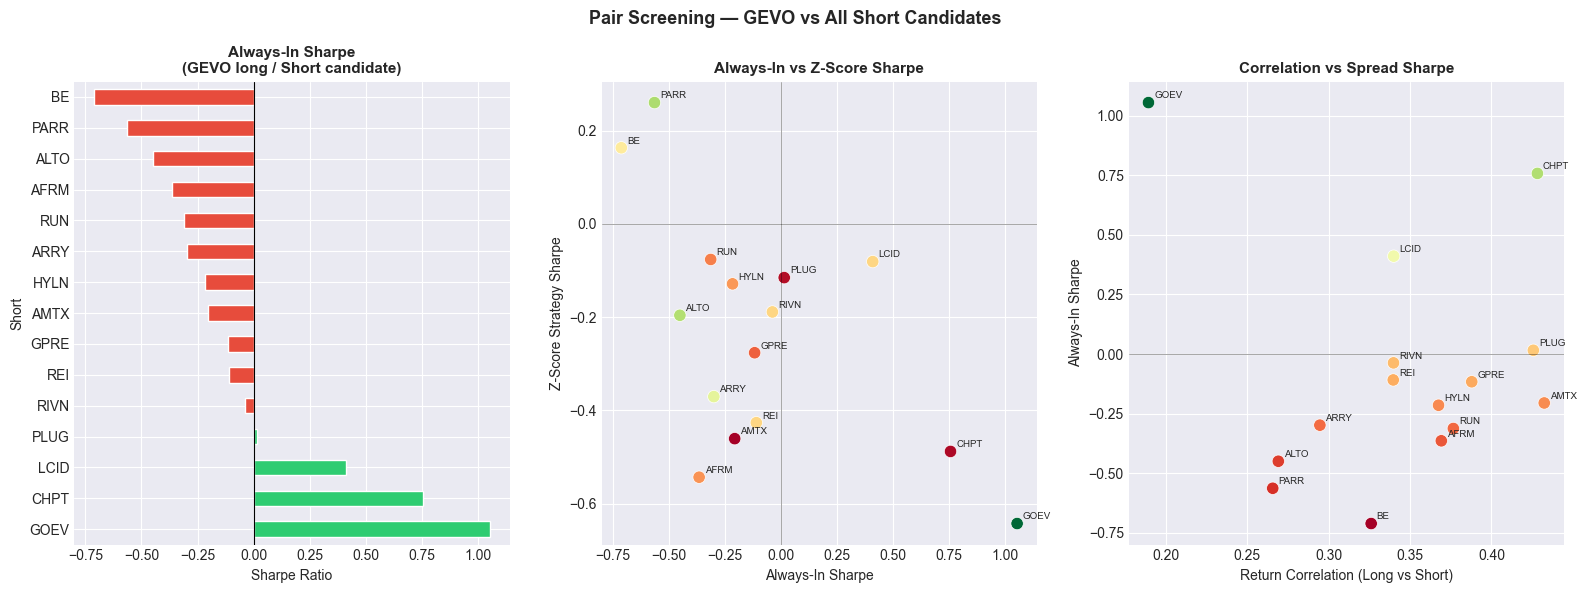

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Sharpe ranking bar chart
top = screen_df.head(15)
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in top['always_sharpe']]
top['always_sharpe'].plot(kind='barh', ax=axes[0], color=colors, edgecolor='white')
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('Always-In Sharpe\n(GEVO long / Short candidate)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Sharpe Ratio')

# Z-score vs always-in Sharpe scatter
valid = screen_df.dropna(subset=['always_sharpe', 'zscore_sharpe'])
axes[1].scatter(valid['always_sharpe'], valid['zscore_sharpe'],
                c=valid['ret_correlation'], cmap='RdYlGn_r',
                s=80, edgecolors='white', linewidth=0.5)
axes[1].axhline(0, color='black', lw=0.6, alpha=0.4)
axes[1].axvline(0, color='black', lw=0.6, alpha=0.4)
for ticker, row in valid.iterrows():
    axes[1].annotate(ticker, (row['always_sharpe'], row['zscore_sharpe']),
                     textcoords='offset points', xytext=(4, 3), fontsize=7)
axes[1].set_xlabel('Always-In Sharpe')
axes[1].set_ylabel('Z-Score Strategy Sharpe')
axes[1].set_title('Always-In vs Z-Score Sharpe', fontsize=11, fontweight='bold')

# Return correlation vs always-in Sharpe
axes[2].scatter(valid['ret_correlation'], valid['always_sharpe'],
                c=valid['always_ret'], cmap='RdYlGn',
                s=80, edgecolors='white', linewidth=0.5)
for ticker, row in valid.iterrows():
    axes[2].annotate(ticker, (row['ret_correlation'], row['always_sharpe']),
                     textcoords='offset points', xytext=(4, 3), fontsize=7)
axes[2].axhline(0, color='black', lw=0.6, alpha=0.4)
axes[2].set_xlabel('Return Correlation (Long vs Short)')
axes[2].set_ylabel('Always-In Sharpe')
axes[2].set_title('Correlation vs Spread Sharpe', fontsize=11, fontweight='bold')

plt.suptitle(f'Pair Screening — {LONG_CANDIDATE} vs All Short Candidates',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + '05_pair_screening.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Primary rank: always-in Sharpe (structural edge)
# Filter: must have at least 10 z-score signals (pair must be tradeable)
tradeable = screen_df[screen_df['n_signals'] >= 5].copy()
if tradeable.empty:
    tradeable = screen_df.copy()

# Composite score: 60% always-in Sharpe, 40% z-score Sharpe (both normalised)
for col in ['always_sharpe', 'zscore_sharpe']:
    tradeable[col + '_rank'] = tradeable[col].rank(ascending=False)

tradeable['composite_rank'] = (0.6 * tradeable['always_sharpe_rank'] +
                                0.4 * tradeable['zscore_sharpe_rank'])
tradeable.sort_values('composite_rank', inplace=True)

BEST_SHORT = tradeable.index[0]
print('=' * 55)
print(f'BEST PAIR: {LONG_CANDIDATE} (Long)  /  {BEST_SHORT} (Short)')
print('=' * 55)
print()
print(tradeable.head(5)[['always_sharpe', 'always_ret', 'always_maxdd',
                          'zscore_sharpe', 'ret_correlation']].round(3).to_string())

BEST PAIR: GEVO (Long)  /  LCID (Short)

       always_sharpe  always_ret  always_maxdd  zscore_sharpe  ret_correlation
Short                                                                         
LCID           0.411       0.257        -0.459         -0.081            0.340
PLUG           0.016       0.058        -0.530         -0.115            0.426
RIVN          -0.037       0.032        -0.591         -0.189            0.340
CHPT           0.758       0.406        -0.443         -0.488            0.428
GOEV           1.055       0.754        -0.571         -0.643            0.190


## 2. Detailed Backtest — Best Pair

### 2a. Weight Split Optimisation

Test long/short weight ratios to find which maximises Sharpe.  
Parameterised as `r = w_long / w_short`. Dollar-neutral is `r = 1`.  
Beta-neutral is `r = β_short / β_long`.

Beta (long  GEVO): 2.433
Beta (short LCID)  : 1.619
Beta-neutral ratio (w_long/w_short): 0.665

Optimal ratio (w_long/w_short): 0.55  →  35.5% long / 64.5% short
Dollar-neutral (1:1)   Sharpe : 0.411
Optimal split          Sharpe : 0.510
Beta-neutral (0.67)  Sharpe : 0.503


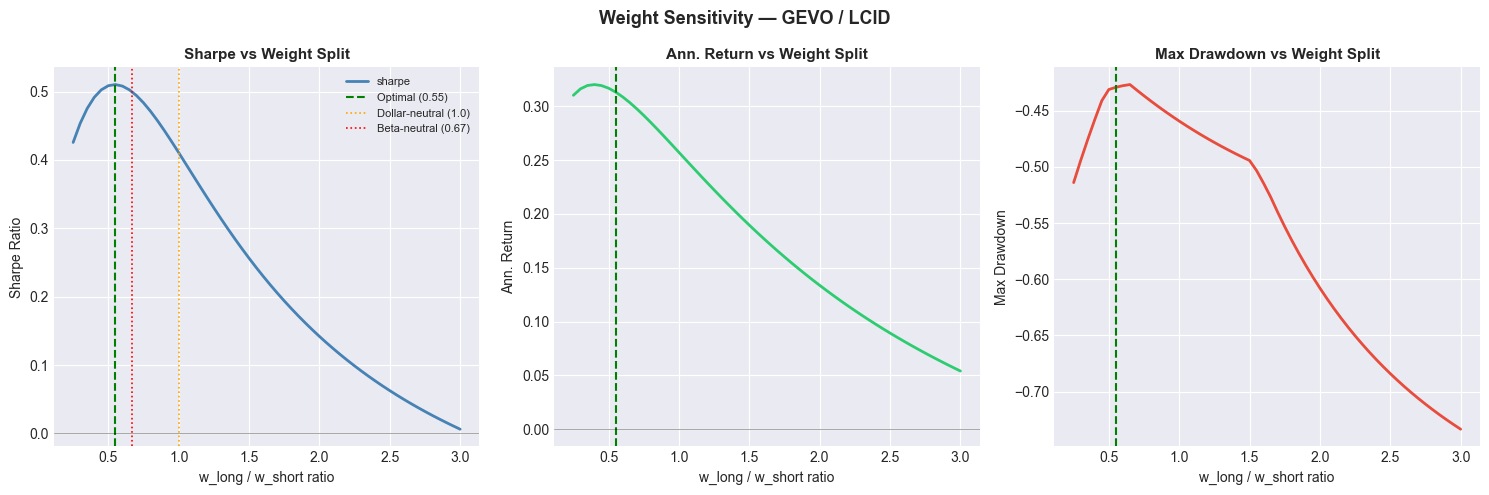

In [7]:
idx  = long_ret.index.intersection(returns[BEST_SHORT].index)
rl   = long_ret.loc[idx]
rs   = returns[BEST_SHORT].loc[idx]

# Beta-neutral ratio
try:
    beta_df = pd.read_parquet(DATA_DIR + 'betas.parquet')
    beta_long  = float(beta_df.loc[LONG_CANDIDATE, 'beta_mkt']) if LONG_CANDIDATE in beta_df.index else 1.0
    beta_short = float(beta_df.loc[BEST_SHORT, 'beta_mkt'])     if BEST_SHORT  in beta_df.index else 1.0
    beta_neutral_ratio = beta_short / beta_long if beta_long != 0 else 1.0
except Exception:
    beta_neutral_ratio = 1.0
    beta_long, beta_short = 1.0, 1.0

print(f'Beta (long  {LONG_CANDIDATE}): {beta_long:.3f}')
print(f'Beta (short {BEST_SHORT})  : {beta_short:.3f}')
print(f'Beta-neutral ratio (w_long/w_short): {beta_neutral_ratio:.3f}')

# Grid search over ratio r = w_long / w_short
# w_long = r/(1+r),  w_short = 1/(1+r)   [gross leverage normalised to 1]
ratios = np.arange(0.25, 3.01, 0.05)
ratio_results = []

for r in ratios:
    wl = r / (1 + r)
    ws = 1 / (1 + r)
    spread = wl * rl - ws * rs
    m = pair_metrics(spread)
    ratio_results.append({'ratio': r, 'w_long': wl, 'w_short': ws,
                          'sharpe': m['sharpe'], 'ann_ret': m['ann_ret'],
                          'ann_vol': m['ann_vol'], 'max_dd': m['max_dd']})

ratio_df = pd.DataFrame(ratio_results).set_index('ratio')

# Best ratio
best_r     = ratio_df['sharpe'].idxmax()
best_wl    = ratio_df.loc[best_r, 'w_long']
best_ws    = ratio_df.loc[best_r, 'w_short']
dollar_r   = 1.0

# Robust nearest lookups for Float64Index across pandas versions
ratio_idx_vals = ratio_df.index.to_numpy(dtype=float)
dn_idx = np.abs(ratio_idx_vals - dollar_r).argmin()
bn_idx = np.abs(ratio_idx_vals - beta_neutral_ratio).argmin()
dn_sharpe = ratio_df.iloc[dn_idx]['sharpe']
bn_sharpe = ratio_df.iloc[bn_idx]['sharpe']

print(f'\nOptimal ratio (w_long/w_short): {best_r:.2f}  →  {best_wl:.1%} long / {best_ws:.1%} short')
print(f'Dollar-neutral (1:1)   Sharpe : {dn_sharpe:.3f}')
print(f'Optimal split          Sharpe : {ratio_df.loc[best_r, "sharpe"]:.3f}')
print(f'Beta-neutral ({beta_neutral_ratio:.2f})  Sharpe : {bn_sharpe:.3f}')

# Plot weight sensitivity
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
ratio_df['sharpe'].plot(ax=axes[0], color='steelblue', linewidth=2)
axes[0].axvline(best_r, color='green',  lw=1.5, linestyle='--', label=f'Optimal ({best_r:.2f})')
axes[0].axvline(1.0,    color='orange', lw=1.2, linestyle=':', label='Dollar-neutral (1.0)')
axes[0].axvline(beta_neutral_ratio, color='red', lw=1.2, linestyle=':', label=f'Beta-neutral ({beta_neutral_ratio:.2f})')
axes[0].axhline(0, color='black', lw=0.6, alpha=0.4)
axes[0].set_xlabel('w_long / w_short ratio')
axes[0].set_ylabel('Sharpe Ratio')
axes[0].set_title('Sharpe vs Weight Split', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=8)

ratio_df['ann_ret'].plot(ax=axes[1], color='#2ecc71', linewidth=2)
axes[1].axvline(best_r, color='green', lw=1.5, linestyle='--')
axes[1].axhline(0, color='black', lw=0.6, alpha=0.4)
axes[1].set_xlabel('w_long / w_short ratio')
axes[1].set_ylabel('Ann. Return')
axes[1].set_title('Ann. Return vs Weight Split', fontsize=11, fontweight='bold')

ratio_df['max_dd'].plot(ax=axes[2], color='#e74c3c', linewidth=2)
axes[2].axvline(best_r, color='green', lw=1.5, linestyle='--')
axes[2].set_xlabel('w_long / w_short ratio')
axes[2].set_ylabel('Max Drawdown')
axes[2].set_title('Max Drawdown vs Weight Split', fontsize=11, fontweight='bold')

plt.suptitle(f'Weight Sensitivity — {LONG_CANDIDATE} / {BEST_SHORT}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + '05_weight_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ── Construct spread at optimal split ────────────────────────────────────────
spread_opt = best_wl * rl - best_ws * rs   # always-in

# ── Z-score on log price ratio ────────────────────────────────────────────────
px_long  = prices[LONG_CANDIDATE].loc[idx]
px_short = prices[BEST_SHORT].loc[idx]
log_spr  = np.log(px_long / px_short)
roll_mu  = log_spr.rolling(ZSCORE_WINDOW).mean()
roll_sd  = log_spr.rolling(ZSCORE_WINDOW).std()
zscore   = (log_spr - roll_mu) / roll_sd

signals   = generate_signals(zscore, ZSCORE_ENTRY, ZSCORE_EXIT)
strat_ret = signals.shift(1).fillna(0) * spread_opt
tc        = signals.diff().abs() * tc_one_way * 2
strat_net = (strat_ret - tc).dropna()

spread_opt_clean = spread_opt.dropna()

# Cumulative series
cum_opt   = (1 + spread_opt_clean).cumprod()   # always-in at optimal split
cum_zscore = (1 + strat_net).cumprod()         # z-score triggered
cum_long  = (1 + rl.reindex(strat_net.index)).cumprod()
cum_short = (1 + rs.reindex(strat_net.index)).cumprod()

# Metrics
m_always_opt = pair_metrics(spread_opt_clean)
m_zscore_opt = pair_metrics(strat_net)

print(f'{"Metric":<25} {"Always-In (optimal split)":>26} {"Z-Score Triggered":>20}')
print('-' * 73)
for k in ['ann_ret', 'ann_vol', 'sharpe', 'max_dd', 'calmar', 'win_rate']:
    a = m_always_opt.get(k, np.nan)
    z = m_zscore_opt.get(k, np.nan)
    print(f'{k:<25} {a:>26.3f} {z:>20.3f}')
print(f'\nOptimal split : {best_wl:.1%} long {LONG_CANDIDATE} / {best_ws:.1%} short {BEST_SHORT}')
print(f'Current z-score: {zscore.iloc[-1]:.3f}  →  Signal: {"LONG SPREAD" if signals.iloc[-1]==1 else "SHORT SPREAD" if signals.iloc[-1]==-1 else "FLAT"}')

Metric                     Always-In (optimal split)    Z-Score Triggered
-------------------------------------------------------------------------
ann_ret                                        0.313                0.009
ann_vol                                        0.516                0.333
sharpe                                         0.510               -0.122
max_dd                                        -0.429               -0.561
calmar                                         0.730                0.017
win_rate                                       0.528                0.197

Optimal split : 35.5% long GEVO / 64.5% short LCID
Current z-score: 1.676  →  Signal: SHORT SPREAD


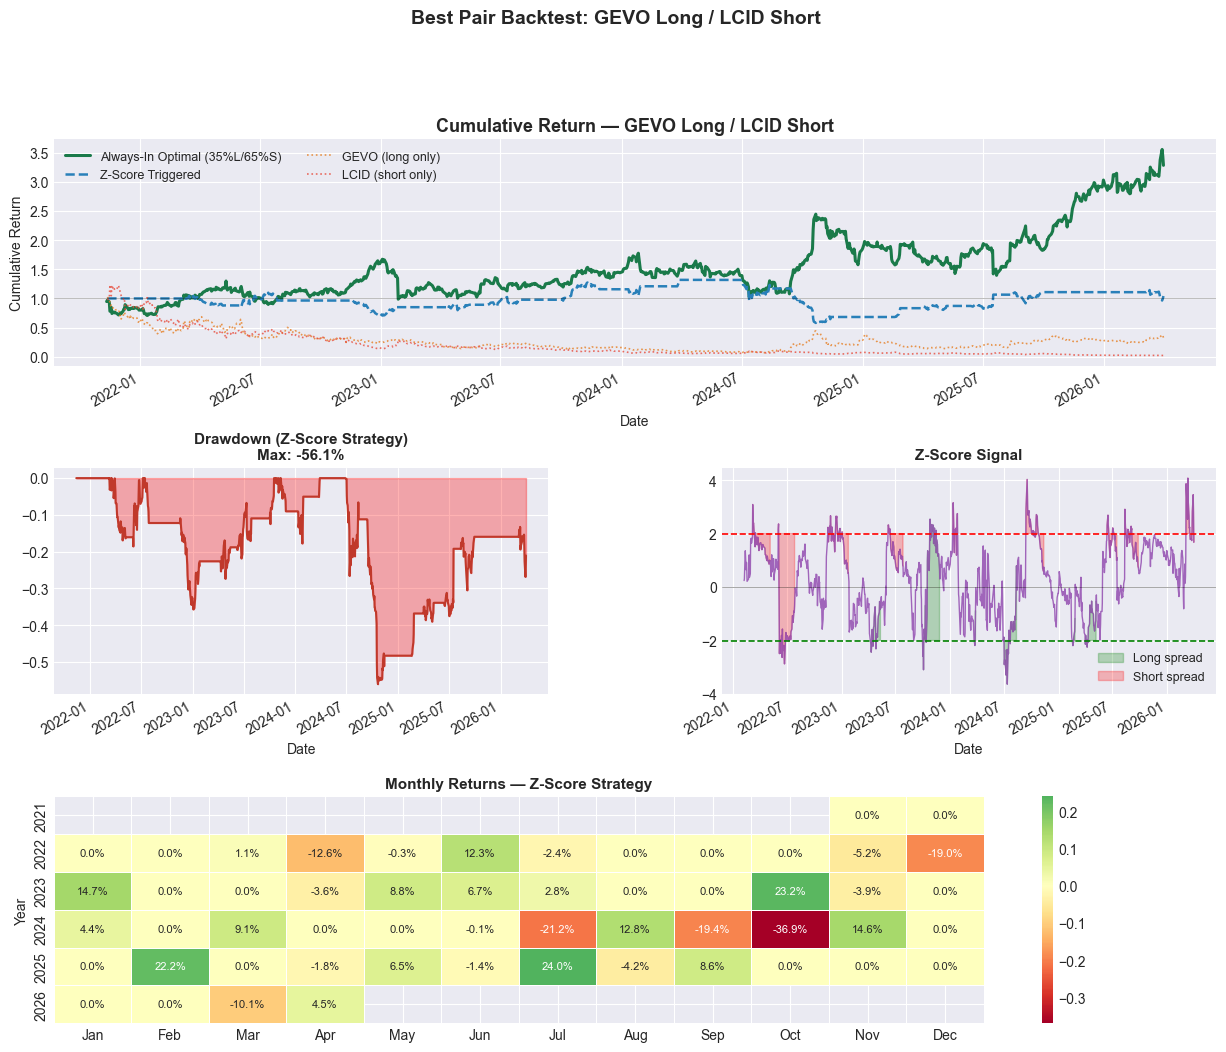

In [9]:
fig = plt.figure(figsize=(15, 13))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# Panel 1: Cumulative returns
ax1 = fig.add_subplot(gs[0, :])
cum_opt.plot(ax=ax1, color='#1a7a4a', linewidth=2.2, label=f'Always-In Optimal ({best_wl:.0%}L/{best_ws:.0%}S)')
cum_zscore.plot(ax=ax1, color='#2980b9', linewidth=1.8, linestyle='--', label='Z-Score Triggered')
cum_long.plot(ax=ax1, color='#e67e22', linewidth=1.2, linestyle=':', alpha=0.8, label=f'{LONG_CANDIDATE} (long only)')
cum_short.plot(ax=ax1, color='#e74c3c', linewidth=1.2, linestyle=':', alpha=0.8, label=f'{BEST_SHORT} (short only)')
ax1.axhline(1, color='black', lw=0.6, alpha=0.3)
ax1.set_title(f'Cumulative Return — {LONG_CANDIDATE} Long / {BEST_SHORT} Short', fontsize=13, fontweight='bold')
ax1.set_ylabel('Cumulative Return')
ax1.legend(fontsize=9, ncol=2)

# Panel 2: Drawdown
ax2 = fig.add_subplot(gs[1, 0])
dd = (cum_zscore / cum_zscore.cummax()) - 1
dd.plot(ax=ax2, color='#c0392b', linewidth=1.5)
ax2.fill_between(dd.index, dd, 0, alpha=0.3, color='red')
ax2.set_title(f'Drawdown (Z-Score Strategy)\nMax: {dd.min():.1%}', fontsize=11, fontweight='bold')

# Panel 3: Z-score with signals
ax3 = fig.add_subplot(gs[1, 1])
zscore.plot(ax=ax3, color='#8e44ad', linewidth=1.0, alpha=0.8)
ax3.fill_between(zscore.index, -ZSCORE_ENTRY, zscore,
                 where=(signals == 1),  alpha=0.25, color='green', label='Long spread')
ax3.fill_between(zscore.index, ZSCORE_ENTRY, zscore,
                 where=(signals == -1), alpha=0.25, color='red',   label='Short spread')
ax3.axhline( ZSCORE_ENTRY,  color='red',   lw=1.2, linestyle='--')
ax3.axhline(-ZSCORE_ENTRY,  color='green', lw=1.2, linestyle='--')
ax3.axhline(0, color='black', lw=0.6, alpha=0.4)
ax3.set_title('Z-Score Signal', fontsize=11, fontweight='bold')
ax3.legend(fontsize=9)

# Panel 4: Monthly heatmap
ax4 = fig.add_subplot(gs[2, :])
monthly = strat_net.resample('ME').apply(lambda x: (1+x).prod()-1)
monthly_df = pd.DataFrame({'Year': monthly.index.year,
                            'Month': monthly.index.month,
                            'Return': monthly.values})
try:
    piv = monthly_df.pivot(index='Year', columns='Month', values='Return')
    col_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    piv.columns = [col_names[c-1] for c in piv.columns]
    sns.heatmap(piv, annot=True, fmt='.1%', cmap='RdYlGn', center=0,
                linewidths=0.5, ax=ax4, annot_kws={'size': 8})
    ax4.set_title('Monthly Returns — Z-Score Strategy', fontsize=11, fontweight='bold')
except Exception:
    monthly.plot(kind='bar', ax=ax4)
    ax4.set_title('Monthly Returns', fontsize=11, fontweight='bold')

plt.suptitle(f'Best Pair Backtest: {LONG_CANDIDATE} Long / {BEST_SHORT} Short',
             fontsize=14, fontweight='bold')
plt.savefig(OUTPUT_DIR + '05_best_pair_backtest.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Save backtest series
bt_out = pd.DataFrame({
    'spread_ret_opt': spread_opt,
    'strat_ret_zscore': strat_net,
    'zscore': zscore,
    'signal': signals,
    'log_spread': log_spr,
})
bt_out.to_parquet(DATA_DIR + 'best_pair_bt.parquet')

# Save best pair metadata
meta = {
    'long':           LONG_CANDIDATE,
    'short':          BEST_SHORT,
    'w_long':         round(best_wl, 4),
    'w_short':        round(best_ws, 4),
    'ratio':          round(best_r, 4),
    'beta_long':      round(beta_long, 4),
    'beta_short':     round(beta_short, 4),
    'beta_neutral_ratio': round(beta_neutral_ratio, 4),
    'sharpe_always_in': round(m_always_opt['sharpe'], 4),
    'sharpe_zscore':    round(m_zscore_opt['sharpe'], 4),
    'ann_ret_always':   round(m_always_opt['ann_ret'], 4),
    'ann_vol_always':   round(m_always_opt['ann_vol'], 4),
    'max_dd_always':    round(m_always_opt['max_dd'], 4),
    'current_zscore':   round(float(zscore.iloc[-1]), 4),
    'current_signal':   int(signals.iloc[-1]),
}
with open(DATA_DIR + 'best_pair_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('Saved best_pair_bt.parquet and best_pair_meta.json')
print()
print('=== SUMMARY ===')
for k, v in meta.items():
    print(f'  {k:<28}: {v}')
print('\nNotebook 05 complete. Run 06_report.ipynb next.')

Saved best_pair_bt.parquet and best_pair_meta.json

=== SUMMARY ===
  long                        : GEVO
  short                       : LCID
  w_long                      : 0.3548
  w_short                     : 0.6452
  ratio                       : 0.55
  beta_long                   : 2.4329
  beta_short                  : 1.619
  beta_neutral_ratio          : 0.6655
  sharpe_always_in            : 0.5103
  sharpe_zscore               : -0.1223
  ann_ret_always              : 0.3132
  ann_vol_always              : 0.5158
  max_dd_always               : -0.4293
  current_zscore              : 1.6764
  current_signal              : -1

Notebook 05 complete. Run 06_report.ipynb next.


## Always-In vs Z-Score

In this notebook, there are two ways to trade the same long/short pair spread.

### Always-In
Always-in means you stay in the pair trade all the time using the chosen long and short weights.

The spread return is:

$$
\text{spread\_opt} = w_L r_L - w_S r_S
$$

Interpretation:
- The trade is always on.
- There is no timing filter.
- This gives the baseline performance of holding the pair continuously.

### Z-Score
Z-score trading only turns the pair on when the spread looks stretched compared with its recent history.

The z-score is built from the log price ratio:

$$
z_t = \frac{\log(P_L / P_S) - \mu_t}{\sigma_t}
$$

Interpretation:
- Large positive or negative values mean the pair is far from its recent average.
- The strategy enters when the z-score crosses the entry threshold.
- It exits when the z-score moves back toward normal.
- If the z-score is near zero, the strategy stays flat.

### Main Difference
- Always-in = always holding the spread.
- Z-score = timing the spread with a signal.

### Why use both
- Always-in is the clean benchmark.
- Z-score tests whether timing improves the pair trade.
- If z-score is better, the signal adds value.
- If always-in is better, the pair may already be efficient or the thresholds may be too strict.